# Fine-tuning d’un modèle de triage médical — SFT puis DPO

Dans ce notebook, je construis une expérience reproductible autour de **Qwen3-1.7B-Base**. J’analyse mes données, j’entraîne d’abord le modèle en SFT, puis je poursuis avec un DPO et je compare les deux modèles sur **exactement le même jeu de test**.

J’utilise **Weights & Biases** pour suivre les paramètres, les pertes, les métriques, les prédictions et les artefacts. Ce travail reste un prototype pédagogique : il ne constitue pas un dispositif médical et ne doit pas être utilisé pour une décision clinique réelle.


## Table des matières

1. [Installation et imports](#1-installation-et-imports)
2. [Configuration reproductible](#2-configuration-reproductible)
3. [Chargement et normalisation](#3-chargement-et-normalisation)
4. [Audit des données](#4-audit-des-données)
5. [Préparation et split SFT](#5-préparation-et-split-sft)
6. [Entraînement SFT](#6-entraînement-sft)
7. [Évaluation complète SFT](#7-évaluation-complète-sft)
8. [Préparation DPO](#8-préparation-dpo)
9. [Entraînement DPO](#9-entraînement-dpo)
10. [Évaluation complète DPO](#10-évaluation-complète-dpo)
11. [Comparaison SFT/DPO](#11-comparaison-sftdpo)
12. [Conclusion et manifeste](#12-conclusion-et-manifeste)


## 1. Installation et imports

J’installe les bibliothèques une seule fois dans l’environnement. Après cette cellule, je redémarre le noyau si Jupyter le demande, puis je poursuis l’exécution.


In [ ]:
# Standard
import gc
import hashlib
import json
import os
import platform
import random
import re
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

# Data, affichage et utilitaires
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import display
from scipy.stats import binomtest
from tqdm.auto import tqdm

# Modèle, entraînement et évaluation
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    set_seed
)
from trl import DPOConfig, DPOTrainer, SFTConfig, SFTTrainer

from transformers import TrainerCallback


In [ ]:
# Vérifie la compatibilité des bibliothèques utilisées par le notebook.
# Le pipeline s'arrête avant le chargement du modèle si une version est invalide.
from importlib.metadata import version
from packaging.specifiers import SpecifierSet
from packaging.version import Version


REQUIRED_VERSIONS = {
    "torch": ">=2.10,<3",
    "transformers": ">=5,<6",
    "trl": "==1.13.0",
    "peft": ">=0.18,<0.20",
    "accelerate": ">=1.10,<2",
    "bitsandbytes": ">=0.48,<0.50",
    "datasets": ">=4.4,<5",
    "wandb": ">=0.22,<0.24"
}

installed_versions = {
    package: version(package)
    for package in REQUIRED_VERSIONS
}

invalid_versions = {
    package: {
        "installed": installed_versions[package],
        "required": requirement
    }
    for package, requirement in REQUIRED_VERSIONS.items()
    if Version(installed_versions[package]) not in SpecifierSet(requirement)
}

if invalid_versions:
    raise RuntimeError(
        f"Versions incompatibles : {invalid_versions}"
    )

version_report = pd.DataFrame([
    {
        "package": package,
        "installed": installed_versions[package],
        "required": requirement,
        "status": "OK"
    }
    for package, requirement in REQUIRED_VERSIONS.items()
])

display(version_report)

## 2. Configuration reproductible

Je centralise les chemins et hyperparamètres dans une seule configuration. Les valeurs peuvent être adaptées, mais elles restent enregistrées dans W&B et dans le manifeste final.


In [3]:
# Configuration reproductible du SFT v2 et du DPO v2.
# Les paramètres SFT historiques sont séparés des optimisations DPO.

@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    model_id: str = "Qwen/Qwen3-1.7B-Base"
    model_revision: str = "main"

    sft_target: int = 5_034
    dpo_target: int = 2_700

    test_size: float = 0.10
    validation_size: float = 0.10

    sft_max_length: int = 1_024
    dpo_max_length: int = 768
    generation_max_new_tokens: int = 5

    sft_train_batch_size: int = 1
    sft_eval_batch_size: int = 1
    sft_gradient_accumulation: int = 8

    dpo_train_batch_size: int = 1
    dpo_eval_batch_size: int = 1
    dpo_gradient_accumulation: int = 8
    dpo_gradient_checkpointing: bool = False

    sft_epochs: float = 3.0
    dpo_epochs: float = 1.0

    sft_learning_rate: float = 2e-4
    dpo_learning_rate: float = 5e-6
    dpo_beta: float = 0.10

    eval_steps: int = 100
    save_steps: int = 100
    logging_steps: int = 10

    wandb_enabled: bool = True
    wandb_project: str = "medical-triage-qwen3"

    strict_dataset_sizes: bool = True
    require_balanced_priorities: bool = True
    priority_balance_tolerance: float = 0.02

    smoke_test: bool = True
    smoke_steps: int = 10


CONFIG = ExperimentConfig()

set_seed(CONFIG.seed)
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)

In [4]:
# Racine du projet et répertoires du fine-tuning

def find_project_root(start: Path | None = None) -> Path:
    """Localise la racine du projet."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw" / "datasets").is_dir():
            return candidate

    raise FileNotFoundError("Répertoire data/raw/datasets introuvable.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "datasets"

# Datasets officiels

SFT_PATH = DATASET_DIR / "sft.jsonl"
DPO_PATH = DATASET_DIR / "dpo.jsonl"

# Datasets riches pour l'audit

SFT_RICH_PATH = DATASET_DIR / "sft_rich.jsonl"
DPO_RICH_PATH = DATASET_DIR / "dpo_rich.jsonl"

for path in (SFT_PATH, DPO_PATH, SFT_RICH_PATH, DPO_RICH_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Dataset introuvable : {path}")


# Variables d'environnement

load_dotenv(PROJECT_ROOT / ".env")

print("WANDB_API_KEY chargée :", bool(os.getenv("WANDB_API_KEY")))
print(f"Projet    : {PROJECT_ROOT}")
print(f"Datasets  : {DATASET_DIR}")
print(f"SFT       : {SFT_PATH.name}")
print(f"SFT rich  : {SFT_RICH_PATH.name}")
print(f"DPO       : {DPO_PATH.name}")
print(f"DPO rich  : {DPO_RICH_PATH.name}")
print(f"Sorties   : {OUTPUT_DIR}")

WANDB_API_KEY chargée : True
Projet    : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent
Datasets  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\raw\datasets
SFT       : sft.jsonl
SFT rich  : sft_rich.jsonl
DPO       : dpo.jsonl
DPO rich  : dpo_rich.jsonl
Sorties   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo


### Suivi Weights & Biases

Je ne place jamais la clé W&B dans le notebook. `wandb.login()` utilise la session existante ou me demande la clé de manière sécurisée ; le mode `offline` reste disponible avec la variable `WANDB_MODE=offline`.


In [5]:
# Configuration W&B.

RUN_STAMP = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
RUN_GROUP = f"qwen3-triage-{RUN_STAMP}"

WANDB_MODE = os.getenv("WANDB_MODE", "online")
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_PROJECT = os.getenv("WANDB_PROJECT", CONFIG.wandb_project)
WANDB_API_KEY = os.getenv("WANDB_API_KEY")

USE_WANDB = CONFIG.wandb_enabled and WANDB_MODE != "disabled"

if USE_WANDB and WANDB_MODE == "online" and not WANDB_API_KEY:
    raise RuntimeError("WANDB_API_KEY absente.")

REPORT_TO = ["wandb"] if USE_WANDB else "none"


def start_wandb_run(stage: str, extra: dict | None = None):
    """Démarre un run W&B traçable."""
    if not USE_WANDB:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{stage}-{RUN_STAMP}",
        group=RUN_GROUP,
        job_type=stage,
        tags=["qwen3", "medical-triage", stage],
        config=asdict(CONFIG) | (extra or {}),
        mode=WANDB_MODE,
        reinit=True
    )


# Répertoires versionnés du run.

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"

SPLIT_DIR = OUTPUT_DIR / "splits"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"

RUN_SPLIT_DIR = SPLIT_DIR / RUN_STAMP
RUN_METRIC_DIR = METRIC_DIR / RUN_STAMP
RUN_MODEL_DIR = MODEL_DIR / RUN_STAMP

for directory in (
    RUN_SPLIT_DIR,
    RUN_METRIC_DIR,
    RUN_MODEL_DIR
):
    directory.mkdir(parents=True, exist_ok=True)


print(
    f"W&B : {WANDB_MODE} | "
    f"clé={'OK' if WANDB_API_KEY else 'absente'} | "
    f"projet={WANDB_PROJECT} | "
    f"groupe={RUN_GROUP}"
)

print(f"Splits   : {RUN_SPLIT_DIR}")
print(f"Métriques: {RUN_METRIC_DIR}")
print(f"Modèles  : {RUN_MODEL_DIR}")

W&B : online | clé=OK | projet=medical-triage-qwen3 | groupe=qwen3-triage-20260922-195422
Splits   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\splits\20260922-195422
Métriques: C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20260922-195422
Modèles  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422


## 3. Chargement et normalisation

Je normalise les variantes de schéma produites par le pipeline précédent. Ensuite, toutes les cellules utilisent le même contrat plat et ne dépendent plus de champs imbriqués.


In [6]:
# Utilitaires JSONL
# Lecture, écriture et traçabilité SHA-256 des datasets.

def read_jsonl(path: Path) -> list[dict]:
    """Charge un fichier JSONL."""
    records = []

    with path.open("r", encoding="utf-8") as stream:
        for line_number, line in enumerate(stream, start=1):
            if not line.strip():
                continue

            value = json.loads(line)

            if not isinstance(value, dict):
                raise ValueError(
                    f"Objet JSON attendu ligne {line_number}: {path}"
                )

            records.append(value)

    return records


def write_jsonl(path: Path, records: list[dict]) -> None:
    """Écrit un fichier JSONL."""
    with path.open("w", encoding="utf-8") as stream:
        for record in records:
            stream.write(json.dumps(record, ensure_ascii=False) + "\n")


def file_sha256(path: Path) -> str:
    """Calcule le SHA-256 d'un fichier."""
    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1_048_576), b""):
            digest.update(block)

    return digest.hexdigest()

In [7]:
# Chargement des datasets d'entraînement
# Les textes médicaux sont conservés intégralement sans normalisation.

def normalize_language(value) -> str:
    """Normalise uniquement le code langue."""
    return str(value or "").lower().strip()


def normalize_priority(value) -> int | None:
    """Valide une priorité P1, P2 ou P3."""
    try:
        priority = int(value)
    except (TypeError, ValueError):
        return None

    return priority if priority in {1, 2, 3} else None


def normalize_sft(record: dict) -> dict:
    """Standardise le schéma SFT sans modifier les textes."""
    return {
        "id": str(record.get("id") or "").strip(),
        "language": normalize_language(record.get("language")),
        "source_split": str(record.get("source_split") or "unsplit").strip(),
        "question": str(record.get("question") or ""),
        "context": str(record.get("context") or ""),
        "answer": str(record.get("answer") or ""),
        "priority": normalize_priority(record.get("priority"))
    }


def normalize_dpo(record: dict) -> dict:
    """Standardise le schéma DPO sans modifier les textes."""
    return {
        "id": str(record.get("id") or "").strip(),
        "language": normalize_language(record.get("language")),
        "source_split": str(record.get("source_split") or "unsplit").strip(),
        "prompt": str(record.get("prompt") or ""),
        "chosen": str(record.get("chosen") or ""),
        "rejected": str(record.get("rejected") or ""),
        "priority": normalize_priority(record.get("priority"))
    }

def render_chat(messages: list[dict], generation: bool = False) -> str:
    """Applique le template Qwen."""
    kwargs = {
        "tokenize": False,
        "add_generation_prompt": generation,
        "enable_thinking": False
    }
    try:
        return tokenizer.apply_chat_template(messages, **kwargs)
    except TypeError:
        kwargs.pop("enable_thinking")
        return tokenizer.apply_chat_template(messages, **kwargs)


def token_length(record: dict) -> int:
    """Compte les tokens de l'exemple complet."""
    text = render_chat(record["prompt"] + record["completion"])
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

In [16]:
# Datasets compacts

sft_records = read_jsonl(SFT_PATH)
dpo_records = read_jsonl(DPO_PATH)

sft_df = pd.DataFrame(
    normalize_sft(record)
    for record in sft_records
)

dpo_df = pd.DataFrame(
    normalize_dpo(record)
    for record in dpo_records
)

# Datasets riches pour l'audit

sft_rich_records = read_jsonl(SFT_RICH_PATH)
dpo_rich_records = read_jsonl(DPO_RICH_PATH)

sft_rich_df = pd.DataFrame(sft_rich_records)
dpo_rich_df = pd.DataFrame(dpo_rich_records)

# Contrôle du chargement

print(f"SFT chargé      : {len(sft_df):,}")
print(f"SFT rich chargé : {len(sft_rich_df):,}")
print(f"DPO chargé      : {len(dpo_df):,}")
print(f"DPO rich chargé : {len(dpo_rich_df):,}")

print(f"\nSFT colonnes : {list(sft_df.columns)}")
print(f"DPO colonnes : {list(dpo_df.columns)}")

SFT chargé      : 5,034
SFT rich chargé : 9,079
DPO chargé      : 3,675
DPO rich chargé : 7,208

SFT colonnes : ['id', 'language', 'source_split', 'question', 'context', 'answer', 'priority']
DPO colonnes : ['id', 'language', 'source_split', 'prompt', 'chosen', 'rejected', 'priority']


## 4. Audit des données

Je bloque l’expérience lorsque le schéma, les identifiants ou les textes sont invalides. Les distributions sont aussi examinées avant le split pour détecter un biais P1/P2/P3 ou linguistique.


In [8]:
def audit(df, required, texts):
    """Bloque toute donnée invalide."""
    assert required <= set(df.columns)
    assert df["id"].notna().all() and df["id"].is_unique
    assert df["language"].isin(["fr", "en"]).all()
    assert df["priority"].isin([1, 2, 3]).all()
    assert all(df[c].fillna("").str.strip().ne("").all() for c in texts)


In [ ]:
# Valide les datasets puis visualise priorités, langues et volumes.
audit(
    sft_df,
    {"id", "language", "source_split", "question", "context", "answer", "priority"},
    ["question"]
)
audit(
    dpo_df,
    {"id", "language", "source_split", "prompt", "chosen", "rejected", "priority"},
    ["prompt", "chosen", "rejected"]
)

assert (dpo_df["chosen"] != dpo_df["rejected"]).all()


# Préparation

priorities = pd.DataFrame({
    "SFT": sft_df["priority"].value_counts().sort_index(),
    "DPO": dpo_df["priority"].value_counts().sort_index()
})

languages = pd.DataFrame({
    "SFT": sft_df["language"].value_counts(),
    "DPO": dpo_df["language"].value_counts()
}).fillna(0)

volumes = pd.Series({
    "SFT": len(sft_df),
    "DPO": len(dpo_df)
})


# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

priorities.plot.bar(
    ax=axes[0],
    title="Distribution des priorités",
    xlabel="Priorité",
    ylabel="Exemples",
    rot=0
)

languages.plot.bar(
    ax=axes[1],
    title="Distribution des langues",
    xlabel="Langue",
    ylabel="Exemples",
    rot=0
)

volumes.plot.bar(
    ax=axes[2],
    title="Volumes finaux",
    xlabel="Dataset",
    ylabel="Exemples",
    rot=0
)

plt.tight_layout()
plt.show()

In [ ]:
# Analyse visuelle du SFT : langues, structure et longueur des entrées.

audit = sft_df.copy()
assert len(audit) == 5034

audit["context"] = audit["context"].fillna("")
audit["answer"] = audit["answer"].fillna("")
audit["has_context"] = audit["context"].str.strip().ne("")
audit["has_answer"] = audit["answer"].str.strip().ne("")

audit["input_chars"] = (
    audit["context"].str.len()
    + audit["question"].fillna("").str.len()
    + audit["answer"].str.len()
)

lang = pd.crosstab(
    audit["priority"],
    audit["language"],
    normalize="index"
) * 100

structure = (
    audit.groupby("priority")[["has_context", "has_answer"]]
    .mean() * 100
)

lengths = (
    audit.groupby("priority")["input_chars"]
    .agg(["mean", "median", lambda x: x.quantile(0.95)])
)
lengths.columns = ["Moyenne", "Médiane", "P95"]


# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lang.plot.bar(
    ax=axes[0],
    title="Langues par priorité",
    xlabel="Priorité",
    ylabel="%",
    rot=0
)

structure.plot.bar(
    ax=axes[1],
    title="Informations disponibles",
    xlabel="Priorité",
    ylabel="%",
    rot=0
)

lengths.plot.bar(
    ax=axes[2],
    title="Longueur des entrées",
    xlabel="Priorité",
    ylabel="Caractères",
    rot=0
)

plt.tight_layout()
plt.show()

In [ ]:
# Vérifie l'équilibre langue × priorité des datasets finaux.

for name, df in {"SFT": sft_df, "DPO": dpo_df}.items():
    counts = df["priority"].value_counts().reindex([1, 2, 3], fill_value=0)
    assert counts.nunique() == 1, f"{name} non équilibré : {counts.to_dict()}"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, {"SFT": sft_df, "DPO": dpo_df}.items()):
    data = pd.crosstab(df["priority"], df["language"])
    data.plot.bar(ax=ax, title=name, xlabel="Priorité", ylabel="Exemples", rot=0)
    ax.bar_label(ax.containers[0], padding=2)
    if len(ax.containers) > 1:
        ax.bar_label(ax.containers[1], padding=2)

plt.tight_layout()
plt.show()

## 5. Préparation et split SFT

Le prompt ne contient jamais la réponse attendue. La sortie impose une première ligne facile à parser, puis conserve l’explication médicale pour entraîner une réponse utile.


In [9]:
# Définit le format clinique commun au SFT et au DPO.

INPUT_LABELS = {
    "fr": ("Contexte", "Question", "Information médicale"),
    "en": ("Context", "Question", "Medical information")
}


def clinical_input(row: pd.Series) -> str:
    """Construit l'entrée médicale."""
    labels = INPUT_LABELS[row["language"]]
    values = [row["context"], row["question"], row["answer"]]

    return "\n\n".join(
        f"{label}: {value}"
        for label, value in zip(labels, values)
        if str(value).strip()
    )

In [10]:
# Prépare les exemples conversationnels SFT.

SYSTEM_PROMPTS = {
    "fr": (
        "Tu es un assistant de triage médical destiné à un service d'urgence. "
        "Évalue la priorité à partir des informations médicales fournies. "
        "P1 = urgence élevée nécessitant une prise en charge rapide, "
        "P2 = urgence modérée, P3 = situation différable. "
        "Ne suppose aucune information absente. "
        "Réponds exactement avec : PRIORITY: P1, PRIORITY: P2 ou PRIORITY: P3."
    ),
    "en": (
        "You are a medical triage assistant for an emergency department. "
        "Assess priority from the medical information provided. "
        "P1 = high urgency requiring prompt care, "
        "P2 = moderate urgency, P3 = deferrable situation. "
        "Do not assume missing information. "
        "Answer exactly with: PRIORITY: P1, PRIORITY: P2 or PRIORITY: P3."
    )
}


def build_sft_example(row: pd.Series) -> dict:
    """Construit un exemple SFT."""
    language = row["language"]

    return {
        "id": row["id"],
        "language": language,
        "source_split": row["source_split"],
        "priority": row["priority"],
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPTS[language]},
            {"role": "user", "content": clinical_input(row)}
        ],
        "completion": [
            {"role": "assistant", "content": f"PRIORITY: P{row['priority']}"}
        ]
    }

In [ ]:
sft_examples = [build_sft_example(row) for _, row in sft_df.iterrows()]

assert len(sft_examples) == 5034
assert all(x["completion"][0]["content"] in {
    "PRIORITY: P1", "PRIORITY: P2", "PRIORITY: P3"
} for x in sft_examples)

display(pd.DataFrame([{
    "langue": x["language"],
    "priorité": f"P{x['priority']}",
    "entrée": x["prompt"][1]["content"][:250],
    "cible": x["completion"][0]["content"]
} for x in sft_examples[:3]]))

In [ ]:
# Réutilise les splits SFT figés et construit leur format v2.

splits = {}

for name in ("train", "validation", "test"):
    ids = {str(x["id"]) for x in read_jsonl(SPLIT_DIR / f"sft_{name}.jsonl")}
    splits[name] = sft_df[sft_df["id"].isin(ids)].copy()
    assert set(splits[name]["id"]) == ids

split_ids = {name: set(df["id"]) for name, df in splits.items()}

assert not any([
    split_ids["train"] & split_ids["validation"],
    split_ids["train"] & split_ids["test"],
    split_ids["validation"] & split_ids["test"]
])
assert sum(map(len, splits.values())) == len(sft_df)

records = {
    name: [build_sft_example(row) for _, row in df.iterrows()]
    for name, df in splits.items()
}

train_records = records["train"]
validation_records = records["validation"]
test_records = records["test"]

assert [len(train_records), len(validation_records), len(test_records)] == [
    4026, 504, 504
]

# Visualise l'équilibre des splits.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, splits.items()):
    pd.crosstab(df["priority"], df["language"]).plot.bar(
        ax=ax, title=f"{name.title()} ({len(df)})", rot=0
    )
    ax.set(xlabel="Priorité", ylabel="Exemples")

plt.tight_layout()
plt.show()

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    trust_remote_code=False
)

tokenizer.padding_side = "left"

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✓ Tokenizer chargé")
print("Pad token :", tokenizer.pad_token)

✓ Tokenizer chargé
Pad token : <|endoftext|>


In [ ]:
sft_lengths = np.array([
    token_length(record)
    for record in train_records + validation_records
])

limit = CONFIG.sft_max_length
over = (sft_lengths > limit).sum()

# Distribution des longueurs

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(sft_lengths, bins=40)
ax.axvline(limit, linestyle="--", label=f"Limite {limit}")
ax.set(
    title=f"Longueur SFT | > limite : {over}/{len(sft_lengths)} ({over / len(sft_lengths):.2%})",
    xlabel="Tokens",
    ylabel="Exemples"
)
ax.legend()

plt.tight_layout()
plt.show()

## 6. Entraînement SFT

J’utilise QLoRA en 4 bits pour réduire la mémoire GPU. La loss porte uniquement sur la complétion assistant, ce qui évite d’entraîner inutilement le modèle à reproduire le prompt.


In [12]:
# Configure QLoRA 4 bits pour le SFT.

if not torch.cuda.is_available():
    raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16 else torch.float16

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE
)

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

In [ ]:
# Configure QLoRA 4 bits pour le SFT.

if not torch.cuda.is_available():
    raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16 else torch.float16

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

In [ ]:
# Initialise le run et prépare le SFT QLoRA.

sft_run = start_wandb_run("sft", {
    "train_rows": len(train_records),
    "validation_rows": len(validation_records),
    "test_rows": len(test_records),
    "source_sha256": file_sha256(SFT_PATH)
})

model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    trust_remote_code=False,
    quantization_config=quantization_config,
    torch_dtype=COMPUTE_DTYPE,
    device_map={"": 0}
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True
)


# Configure le run SFT.

run_kind = "smoke" if CONFIG.smoke_test else "final"

SFT_CHECKPOINT_DIR = RUN_MODEL_DIR / f"sft_checkpoints_{run_kind}"
SFT_MODEL_PATH = RUN_MODEL_DIR / f"sft_adapter_{run_kind}"

sft_args = SFTConfig(
    output_dir=str(SFT_CHECKPOINT_DIR),
    num_train_epochs=CONFIG.sft_epochs,
    max_steps=CONFIG.smoke_steps if CONFIG.smoke_test else -1,
    learning_rate=CONFIG.sft_learning_rate,
    per_device_train_batch_size=CONFIG.sft_train_batch_size,
    per_device_eval_batch_size=CONFIG.sft_eval_batch_size,
    gradient_accumulation_steps=CONFIG.sft_gradient_accumulation,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    bf16=BF16,
    fp16=not BF16,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    max_length=CONFIG.sft_max_length,
    completion_only_loss=True,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=10 if CONFIG.smoke_test else CONFIG.eval_steps,
    save_steps=10 if CONFIG.smoke_test else CONFIG.save_steps,
    logging_steps=CONFIG.logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to=REPORT_TO,
    run_name=f"sft-{run_kind}-{RUN_STAMP}",
    seed=CONFIG.seed,
    data_seed=CONFIG.seed,
    dataset_num_proc=1
)

sft_trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=Dataset.from_list(train_records),
    eval_dataset=Dataset.from_list(validation_records),
    processing_class=tokenizer,
    peft_config=lora_config,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [ ]:
# Vérifie le masque de loss et la cible assistant SFT.

batch = next(iter(sft_trainer.get_train_dataloader()))
input_ids = batch["input_ids"][0]
labels = batch["labels"][0]

mask = labels.ne(-100)
positions = mask.nonzero(as_tuple=True)[0]

assert positions.numel() > 0, "Aucun token supervisé."
assert positions[0] > 0, "Prompt non masqué."
assert labels[:positions[0]].eq(-100).all(), "Masquage incorrect."

target = tokenizer.decode(labels[mask], skip_special_tokens=True).strip()
assert "PRIORITY:" in target, f"Cible incorrecte : {target!r}"

display(pd.DataFrame([{
    "tokens": len(input_ids),
    "ignorés": (~mask).sum().item(),
    "supervisés": mask.sum().item(),
    "prompt masqué": True,
    "cible": target
}]))

In [ ]:
# Entraîne, évalue et sauvegarde le meilleur adapter SFT.

sft_train_output = sft_trainer.train()
sft_validation_metrics = sft_trainer.evaluate()

sft_trainer.save_model(str(SFT_MODEL_PATH))
tokenizer.save_pretrained(SFT_MODEL_PATH)

results = {
    **{f"train_{k}": v for k, v in sft_train_output.metrics.items()},
    **sft_validation_metrics
}

(RUN_METRIC_DIR / "sft_training_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8"
)


# Journalise la validation et l'adapter.

if sft_run:
    sft_run.log({
        f"sft/{key}": value
        for key, value in sft_validation_metrics.items()
    })

    artifact = wandb.Artifact(
        "qwen3-triage-sft-adapter",
        type="model",
        metadata={"run_stamp": RUN_STAMP}
    )
    artifact.add_dir(str(SFT_MODEL_PATH))
    sft_run.log_artifact(artifact)
    sft_run.finish()


# Synthèse entraînement + validation.

display(pd.DataFrame(
    [{"métrique": key, "valeur": value} for key, value in results.items()]
))

## 7. Évaluation complète SFT

Je compte les sorties non parsables comme des erreurs techniques de classe `0`. La matrice possède donc une colonne « INVALID » : aucune génération ratée ne disparaît des métriques.


In [13]:
# Score P1/P2/P3 par vraisemblance conditionnelle.

LABELS = [1, 2, 3]
CLASS_NAMES = ["P1 - maximale", "P2 - modérée", "P3 - différée"]


def score_priorities(model, frame: pd.DataFrame) -> pd.DataFrame:
    """Classe chaque exemple parmi P1, P2 et P3."""
    model.eval()
    results = []

    targets = {
        p: tokenizer(
            f"PRIORITY: P{p}",
            add_special_tokens=False
        )["input_ids"]
        for p in LABELS
    }

    for _, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc="Scoring",
        unit="record"
    ):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPTS[row["language"]]},
            {"role": "user", "content": clinical_input(row)}
        ]

        prompt = render_chat(messages, generation=True)
        prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]

        scores = {}

        for priority, target_ids in targets.items():
            max_prompt = CONFIG.sft_max_length - len(target_ids)
            ids = prompt_ids[-max_prompt:] + target_ids
            input_ids = torch.tensor([ids], device=model.device)

            with torch.inference_mode():
                logits = model(input_ids=input_ids).logits

            start = len(ids) - len(target_ids) - 1
            logits = logits[0, start:start + len(target_ids)].float()
            log_probs = torch.log_softmax(logits, dim=-1)

            token_ids = torch.tensor(target_ids, device=model.device)
            index = torch.arange(len(target_ids), device=model.device)

            scores[priority] = log_probs[index, token_ids].mean().item()

        predicted = max(scores, key=scores.get)

        results.append({
            "id": row["id"],
            "language": row["language"],
            "expected": int(row["priority"]),
            "predicted": predicted,
            "output": f"PRIORITY: P{predicted}",
            **{f"score_p{p}": scores[p] for p in LABELS}
        })

    return pd.DataFrame(results)

In [14]:
# Calcule les métriques globales, par classe et par langue.

def evaluate_predictions(results: pd.DataFrame, stage: str):
    """Évalue les prédictions P1/P2/P3."""
    y_true = results["expected"].astype(int)
    y_pred = results["predicted"].astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )

    metrics = {
        "stage": stage,
        "rows": len(results),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        )
    }

    classes = pd.DataFrame({
        "class": [f"P{x}" for x in LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int)
    })

    for language, group in results.groupby("language"):
        metrics[f"accuracy_{language}"] = accuracy_score(
            group["expected"], group["predicted"]
        )
        metrics[f"f1_macro_{language}"] = f1_score(
            group["expected"], group["predicted"],
            labels=LABELS, average="macro", zero_division=0
        )

    return metrics, classes, confusion_matrix(y_true, y_pred, labels=LABELS)


# Mesure les erreurs de sous-triage.

def undertriage_report(results: pd.DataFrame, stage: str):
    """Mesure le sous-triage."""
    rows = []

    for expected, predicted in [(1, 2), (1, 3), (2, 3)]:
        support = results["expected"].eq(expected).sum()
        count = (
            results["expected"].eq(expected)
            & results["predicted"].eq(predicted)
        ).sum()

        rows.append({
            "stage": stage,
            "transition": f"P{expected} → P{predicted}",
            "count": int(count),
            "support": int(support),
            "rate_pct": 100 * count / support if support else 0
        })

    details = results[results["expected"] < results["predicted"]].copy()
    details["stage"] = stage

    return pd.DataFrame(rows), details


# Visualise les performances.

def display_evaluation(classes, matrix, stage):
    """Affiche métriques par classe et matrice de confusion."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    classes.set_index("class")[["precision", "recall", "f1"]].plot.bar(
        ax=axes[0], ylim=(0, 1), rot=0,
        title=f"Métriques par classe | {stage}"
    )
    axes[0].set(xlabel="Priorité", ylabel="Score")

    axes[1].imshow(matrix)

    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, matrix[i, j], ha="center", va="center")

    axes[1].set(
        title=f"Matrice de confusion | {stage}",
        xlabel="Prédiction",
        ylabel="Classe attendue",
        xticks=range(3),
        yticks=range(3),
        xticklabels=["P1", "P2", "P3"],
        yticklabels=["P1", "P2", "P3"]
    )

    plt.tight_layout()
    plt.show()

    return fig

In [ ]:
# Évalue le SFT v2 sur les 504 exemples figés.

sft_results_df = score_priorities(
    sft_trainer.model,
    splits["test"]
)

sft_metrics, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    "SFT v2"
)

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    "SFT v2"
)

sft_figure = display_evaluation(
    sft_class_metrics,
    sft_confusion,
    "SFT v2"
)

display(pd.DataFrame([sft_metrics]))
display(sft_undertriage)


# Sauvegarde le benchmark du run.

sft_figure.savefig(
    RUN_METRIC_DIR / "sft_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

write_jsonl(
    RUN_METRIC_DIR / "sft_predictions.jsonl",
    sft_results_df.to_dict("records")
)

write_jsonl(
    RUN_METRIC_DIR / "sft_undertriage_details.jsonl",
    sft_undertriage_details.to_dict("records")
)

(RUN_METRIC_DIR / "sft_metrics.json").write_text(
    json.dumps(sft_metrics, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

plt.close(sft_figure)

In [ ]:
# Journalise le benchmark final SFT v2 dans W&B.

sft_test_run = start_wandb_run("sft-test", {
    "test_rows": len(sft_results_df),
    "inference_method": "conditional_priority_scoring",
    "source_sha256": file_sha256(SFT_PATH)
})

if sft_test_run:
    sft_test_run.log({
        **{
            f"test/{key}": value
            for key, value in sft_metrics.items()
            if isinstance(value, (int, float))
        },
        "test/predictions": wandb.Table(dataframe=sft_results_df),
        "test/undertriage": wandb.Table(dataframe=sft_undertriage),
        "test/confusion_matrix": wandb.Image(
            str(RUN_METRIC_DIR / "sft_confusion_matrix.png")
        )
    })

    sft_test_run.finish()

## libere VRAM

In [ ]:
# Libère le SFT et la mémoire GPU.

for name in (
    "sft_trainer",
    "model",
    "sft_train_output"
):
    globals().pop(name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

    free, total = torch.cuda.mem_get_info()

    print(
        f"✓ SFT libéré | "
        f"VRAM libre : {free / 1024**3:.2f} / {total / 1024**3:.2f} Go"
    )

## 8. Préparation DPO

Le DPO apprend ici à préférer une réponse de meilleure qualité, pas à inventer une autre étiquette. J’utilise donc **la même priorité validée** dans `chosen` et `rejected` ; seule la qualité de l’évaluation médicale varie.


In [17]:
# Vérifie la provenance du DPO final sans modifier les données.
# Le compact reste l'unique dataset utilisé pour l'entraînement.

dpo_ids = set(dpo_df["id"])
dpo_rich_df["id"] = dpo_rich_df["id"].astype(str)

missing_ids = dpo_ids - set(dpo_rich_df["id"])

assert dpo_df["id"].is_unique
assert dpo_rich_df["id"].is_unique
assert not missing_ids

dpo_rich_final_df = dpo_rich_df[
    dpo_rich_df["id"].isin(dpo_ids)
].copy()

assert len(dpo_rich_final_df) == len(dpo_df)

print(f"DPO compact   : {len(dpo_df):,}")
print(f"DPO rich      : {len(dpo_rich_df):,}")
print(f"DPO rich final: {len(dpo_rich_final_df):,}")
print(f"IDs manquants : {len(missing_ids):,}")

print("\nColonnes DPO rich :")
print(sorted(dpo_rich_final_df.columns))

DPO compact   : 3,675
DPO rich      : 7,208
DPO rich final: 3,675
IDs manquants : 0

Colonnes DPO rich :
['answer', 'chosen_medical', 'clean_content_hash', 'context', 'dpo_final_priority', 'dpo_pair', 'dpo_priority_validation', 'id', 'language', 'medical_extraction', 'medical_knowledge', 'patient', 'prompt_medical', 'question', 'rejected_medical', 'triage_engine_decision']


In [18]:
# Vérifie que le DPO compact reproduit exactement priorité, chosen et rejected du rich.
# Le rich reste uniquement une source d'audit et de traçabilité.
rich_by_id = dpo_rich_final_df.set_index("id")

priority_errors = 0
chosen_errors = 0
rejected_errors = 0

for _, row in dpo_df.iterrows():
    rich = rich_by_id.loc[row["id"]]
    pair = rich["dpo_pair"]

    priority_errors += int(
        row["priority"] != int(rich["dpo_final_priority"])
    )
    chosen_errors += int(
        row["chosen"] != pair["chosen"]
    )
    rejected_errors += int(
        row["rejected"] != pair["rejected"]
    )

print(f"Priorités différentes : {priority_errors:,}")
print(f"Chosen différents     : {chosen_errors:,}")
print(f"Rejected différents   : {rejected_errors:,}")

if priority_errors or chosen_errors or rejected_errors:
    raise ValueError("Incohérence entre DPO compact et rich.")

print("\nValidation des priorités :")
print(
    dpo_rich_final_df["dpo_priority_validation"]
    .value_counts(dropna=False)
)

Priorités différentes : 0
Chosen différents     : 0
Rejected différents   : 0

Validation des priorités :
dpo_priority_validation
engine_priority              3044
unique_candidate_priority     631
Name: count, dtype: int64


In [19]:
# Utilise le SFT du run expérimental courant.

SFT_MODEL_PATH = RUN_MODEL_DIR / "sft_adapter_final"

assert SFT_MODEL_PATH.exists(), f"SFT introuvable : {SFT_MODEL_PATH}"

print(f"✓ SFT : {SFT_MODEL_PATH}")

✓ SFT : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422\sft_adapter_final


In [20]:
# Réutilise les splits SFT figés du run.

splits = {}

for name in ("train", "validation", "test"):
    ids = {
        str(x["id"])
        for x in read_jsonl(RUN_SPLIT_DIR / f"sft_{name}.jsonl")
    }

    splits[name] = sft_df[
        sft_df["id"].isin(ids)
    ].copy()

    assert set(splits[name]["id"]) == ids

assert [len(splits[name]) for name in ("train", "validation", "test")] == [
    4026, 504, 504
]

print("✓ Splits SFT figés du run rechargés")

✓ Splits SFT figés du run rechargés


In [21]:
# Retire du DPO les prompts identiques aux entrées du test SFT.

def text_hash(value: str) -> str:
    """Hash textuel normalisé."""
    text = " ".join(str(value).lower().split())
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


test_hashes = {
    text_hash(clinical_input(row))
    for _, row in splits["test"].iterrows()
}

dpo_df = dpo_df.copy()
dpo_df["prompt_hash"] = dpo_df["prompt"].map(text_hash)

leakage_mask = dpo_df["prompt_hash"].isin(test_hashes)
leakage_count = int(leakage_mask.sum())
dpo_rows_before = len(dpo_df)

dpo_df = dpo_df[~leakage_mask].reset_index(drop=True)

assert not dpo_df.empty

print(f"DPO avant filtrage : {dpo_rows_before:,}")
print(f"Chevauchements     : {leakage_count:,}")
print(f"DPO après filtrage : {len(dpo_df):,}")
print("\nPriorités :")
print(dpo_df["priority"].value_counts().sort_index())

DPO avant filtrage : 3,675
Chevauchements     : 0
DPO après filtrage : 3,675

Priorités :
priority
1    1225
2    1225
3    1225
Name: count, dtype: int64


In [22]:
# Vérifie les hash amont entre test SFT et DPO.

test_ids = set(splits["test"]["id"])

sft_test_rich = pd.DataFrame(
    record for record in read_jsonl(SFT_RICH_PATH)
    if str(record["id"]) in test_ids
)

assert len(sft_test_rich) == len(test_ids)

sft_hashes = set(
    sft_test_rich["clean_content_hash"].dropna().astype(str)
)

dpo_hashes = set(
    dpo_rich_final_df["clean_content_hash"].dropna().astype(str)
)

shared_hashes = sft_hashes & dpo_hashes

print(f"SFT test rich   : {len(sft_test_rich):,}")
print(f"Hashes SFT test : {len(sft_hashes):,}")
print(f"Hashes DPO      : {len(dpo_hashes):,}")
print(f"Hashes communs  : {len(shared_hashes):,}")

if shared_hashes:
    raise ValueError(
        f"Fuite SFT test ↔ DPO : {len(shared_hashes)} hash(es)"
    )

print("✓ Aucune contamination SFT test ↔ DPO")

SFT test rich   : 504
Hashes SFT test : 504
Hashes DPO      : 3,675
Hashes communs  : 0
✓ Aucune contamination SFT test ↔ DPO


In [23]:
# Sélectionne 2 700 DPO validés et équilibrés P1/P2/P3.

DPO_TARGET_ROWS = 2_700
DPO_ROWS_PER_PRIORITY = 900

validation_rank = {
    "engine_priority": 2,
    "unique_candidate_priority": 1
}

dpo_quality_df = dpo_df.merge(
    dpo_rich_final_df[["id", "dpo_priority_validation"]],
    on="id",
    how="left",
    validate="one_to_one"
)

dpo_quality_df["validation_rank"] = (
    dpo_quality_df["dpo_priority_validation"]
    .map(validation_rank)
    .fillna(0)
    .astype(int)
)

dpo_quality_df = dpo_quality_df.sample(
    frac=1,
    random_state=CONFIG.seed
)

dpo_selected_df = (
    dpo_quality_df
    .sort_values("validation_rank", ascending=False, kind="stable")
    .groupby("priority", group_keys=False)
    .head(DPO_ROWS_PER_PRIORITY)
    .reset_index(drop=True)
)

assert len(dpo_selected_df) == DPO_TARGET_ROWS
assert dpo_selected_df["id"].is_unique
assert dpo_selected_df["priority"].value_counts().eq(
    DPO_ROWS_PER_PRIORITY
).all()

write_jsonl(
    RUN_METRIC_DIR / "dpo_selected.jsonl",
    dpo_selected_df.to_dict("records")
)

display(pd.crosstab(
    dpo_selected_df["priority"],
    dpo_selected_df["dpo_priority_validation"]
))

dpo_priority_validation,engine_priority,unique_candidate_priority
priority,,
1,594,306
2,900,0
3,900,0


In [26]:
# Split DPO v2 stratifié 90/10 et sauvegarde du run.

dpo_train_df, dpo_validation_df = train_test_split(
    dpo_selected_df,
    test_size=0.10,
    random_state=CONFIG.seed,
    stratify=dpo_selected_df["priority"]
)

assert len(dpo_train_df) == 2430
assert len(dpo_validation_df) == 270
assert set(dpo_train_df["id"]).isdisjoint(dpo_validation_df["id"])
assert dpo_train_df["priority"].value_counts().eq(810).all()
assert dpo_validation_df["priority"].value_counts().eq(90).all()


# Construit le format conversationnel DPO.

def build_dpo_example(row: pd.Series) -> dict:
    """Construit un exemple DPO."""
    return {
        "id": row["id"],
        "language": row["language"],
        "priority": int(row["priority"]),
        "prompt": [{"role": "user", "content": row["prompt"]}],
        "chosen": [{"role": "assistant", "content": row["chosen"]}],
        "rejected": [{"role": "assistant", "content": row["rejected"]}]
    }


dpo_train_records = [
    build_dpo_example(row)
    for _, row in dpo_train_df.iterrows()
]

dpo_validation_records = [
    build_dpo_example(row)
    for _, row in dpo_validation_df.iterrows()
]


# Fige exactement les données DPO utilisées par ce run.

DPO_SPLIT_DIR = RUN_SPLIT_DIR / "dpo"
DPO_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

write_jsonl(
    DPO_SPLIT_DIR / "dpo_train.jsonl",
    dpo_train_records
)

write_jsonl(
    DPO_SPLIT_DIR / "dpo_validation.jsonl",
    dpo_validation_records
)

dpo_split_manifest = {
    "run_stamp": RUN_STAMP,
    "seed": CONFIG.seed,
    "selected_rows": len(dpo_selected_df),
    "train_rows": len(dpo_train_records),
    "validation_rows": len(dpo_validation_records),
    "train_sha256": file_sha256(DPO_SPLIT_DIR / "dpo_train.jsonl"),
    "validation_sha256": file_sha256(DPO_SPLIT_DIR / "dpo_validation.jsonl")
}

(DPO_SPLIT_DIR / "dpo_split_manifest.json").write_text(
    json.dumps(dpo_split_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8"
)


# Contrôle final.

display(pd.DataFrame({
    "train": dpo_train_df["priority"].value_counts().sort_index(),
    "validation": dpo_validation_df["priority"].value_counts().sort_index()
}))

,train,validation
priority,,
1,810,90
2,810,90
3,810,90


In [27]:
# Mesure séparément prompt, chosen et rejected pour optimiser le DPO.
def dpo_token_lengths(record: dict) -> dict:
    """Mesure les longueurs DPO utiles."""
    prompt_text = render_chat(
        record["prompt"],
        generation=True
    )
    chosen_text = render_chat(
        record["prompt"] + record["chosen"]
    )
    rejected_text = render_chat(
        record["prompt"] + record["rejected"]
    )

    prompt_tokens = len(tokenizer(
        prompt_text,
        add_special_tokens=False
    )["input_ids"])

    chosen_tokens = len(tokenizer(
        chosen_text,
        add_special_tokens=False
    )["input_ids"])

    rejected_tokens = len(tokenizer(
        rejected_text,
        add_special_tokens=False
    )["input_ids"])

    return {
        "prompt": prompt_tokens,
        "chosen": chosen_tokens,
        "rejected": rejected_tokens,
        "max_pair": max(chosen_tokens, rejected_tokens)
    }


dpo_length_df = pd.DataFrame([
    dpo_token_lengths(record)
    for record in dpo_train_records + dpo_validation_records
])

display(
    dpo_length_df.describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

truncated = int(
    (dpo_length_df["max_pair"] > CONFIG.dpo_max_length).sum()
)

rate = truncated / len(dpo_length_df) * 100

print(
    f"> {CONFIG.dpo_max_length} tokens : "
    f"{truncated:,}/{len(dpo_length_df):,} ({rate:.2f} %)"
)

,prompt,chosen,rejected,max_pair
count,2700.000000,2700.000000,2700.000000,2700.000000
mean,164.241852,476.648519,432.790370,496.324074
std,75.728941,128.511038,130.880368,126.709406
min,25.000000,109.000000,111.000000,145.000000
50%,147.000000,466.000000,414.000000,482.000000
90%,245.000000,638.000000,604.100000,655.100000
95%,317.050000,713.000000,677.150000,728.000000
99%,473.000000,876.020000,845.000000,890.030000
max,838.000000,1160.000000,1213.000000,1213.000000


> 768 tokens : 85/2,700 (3.15 %)


In [28]:
def dpo_prompt_length(record: dict) -> int:
    """Compte les tokens du prompt DPO."""
    text = render_chat(record["prompt"], generation=True)
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


dpo_prompt_lengths = np.array([
    dpo_prompt_length(record)
    for record in dpo_train_records + dpo_validation_records
])

display(
    pd.Series(dpo_prompt_lengths)
    .describe(percentiles=[0.50, 0.90, 0.95, 0.99])
    .to_frame("prompt_tokens")
)

over_limit = int((dpo_prompt_lengths >= CONFIG.dpo_max_length).sum())

print(
    f">= {CONFIG.dpo_max_length} tokens : "
    f"{over_limit:,}/{len(dpo_prompt_lengths):,} "
    f"({over_limit / len(dpo_prompt_lengths) * 100:.2f} %)"
)

,prompt_tokens
count,2700.000000
mean,164.241852
std,75.728941
min,25.000000
50%,147.000000
90%,245.000000
95%,317.050000
99%,473.000000
max,838.000000


>= 768 tokens : 1/2,700 (0.04 %)


## 9. Entraînement DPO

Je repars du modèle SFT et j’utilise une référence implicite adaptée au mode PEFT. Le learning rate est volontairement plus faible afin de préserver la classification apprise pendant le SFT.


In [29]:
# Recharge le SFT comme point de départ du DPO.

if "model" in globals():
    del model

gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    quantization_config=quantization_config,
    device_map={"": 0},
    dtype=COMPUTE_DTYPE,
    attn_implementation="sdpa"
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=False
)

model = PeftModel.from_pretrained(
    model,
    SFT_MODEL_PATH,
    adapter_name="default",
    is_trainable=True
)

model.load_adapter(
    SFT_MODEL_PATH,
    adapter_name="ref",
    is_trainable=False
)

model.set_adapter("default")
model.config.use_cache = False

print("✓ SFT chargé pour le DPO")
print("Adapters :", list(model.peft_config))
print("Actif    :", model.active_adapter)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✓ SFT chargé pour le DPO
Adapters : ['default', 'ref']
Actif    : default
trainable params: 17,432,576 || all params: 1,755,440,128 || trainable%: 0.9931


In [30]:
# Configure le DPO.

DPO_CHECKPOINT_DIR = RUN_MODEL_DIR / "dpo_checkpoints"
DPO_MODEL_PATH = RUN_MODEL_DIR / "dpo_adapter"

dpo_args = DPOConfig(
    output_dir=str(DPO_CHECKPOINT_DIR),
    num_train_epochs=CONFIG.dpo_epochs,
    max_steps=CONFIG.smoke_steps if CONFIG.smoke_test else -1,
    learning_rate=CONFIG.dpo_learning_rate,
    beta=CONFIG.dpo_beta,
    loss_type=["sigmoid"],
    per_device_train_batch_size=CONFIG.dpo_train_batch_size,
    per_device_eval_batch_size=CONFIG.dpo_eval_batch_size,
    gradient_accumulation_steps=CONFIG.dpo_gradient_accumulation,
    gradient_checkpointing=False,
    bf16=BF16,
    fp16=not BF16,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    max_length=CONFIG.dpo_max_length,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=CONFIG.eval_steps,
    save_steps=CONFIG.save_steps,
    logging_steps=CONFIG.logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to=REPORT_TO,
    run_name=f"dpo-{RUN_STAMP}",
    seed=CONFIG.seed,
    data_seed=CONFIG.seed,
    dataset_num_proc=1
)

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_args,
    train_dataset=Dataset.from_list(dpo_train_records),
    eval_dataset=Dataset.from_list(dpo_validation_records),
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

mode = f"SMOKE ({CONFIG.smoke_steps} steps)" if CONFIG.smoke_test else "COMPLET"

print(f"✓ DPOTrainer créé | {mode}")
print(f"Checkpoints : {DPO_CHECKPOINT_DIR}")
print(f"Adapter     : {DPO_MODEL_PATH}")

Tokenizing train dataset (num_proc=1):   0%|          | 0/2430 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset (num_proc=1):   0%|          | 0/2430 [00:00<?, ? example…

Tokenizing eval dataset (num_proc=1):   0%|          | 0/270 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset (num_proc=1):   0%|          | 0/270 [00:00<?, ? examples/…

✓ DPOTrainer créé | SMOKE (10 steps)
Checkpoints : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422\dpo_checkpoints
Adapter     : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422\dpo_adapter


In [31]:
# Vérifie la mémoire GPU après chargement du SFT.

free, total = torch.cuda.mem_get_info()

print("CUDA allouée :", round(torch.cuda.memory_allocated() / 1024**3, 2), "GiB")
print("CUDA réservée:", round(torch.cuda.memory_reserved() / 1024**3, 2), "GiB")
print("Pic CUDA      :", round(torch.cuda.max_memory_allocated() / 1024**3, 2), "GiB")
print("GPU libre     :", round(free / 1024**3, 2), "/", round(total / 1024**3, 2), "GiB")

CUDA allouée : 1.94 GiB
CUDA réservée: 2.67 GiB
Pic CUDA      : 2.42 GiB
GPU libre     : 2.28 / 6.0 GiB


In [33]:
# Affiche la progression réelle du DPO.

class DPOProgressCallback(TrainerCallback):
    """Affiche la progression DPO."""

    def on_train_begin(self, args, state, control, **kwargs):
        self.bar = tqdm(
            total=state.max_steps,
            desc="DPO",
            unit="step"
        )

    def on_step_end(self, args, state, control, **kwargs):
        self.bar.n = state.global_step
        self.bar.refresh()

    def on_train_end(self, args, state, control, **kwargs):
        self.bar.close()


dpo_trainer.add_callback(DPOProgressCallback())

In [34]:
# Initialise le run W&B DPO.

dpo_run = start_wandb_run("dpo", {
    "train_rows": len(dpo_train_records),
    "validation_rows": len(dpo_validation_records),
    "available_rows": len(dpo_df),
    "selected_rows": len(dpo_selected_df),
    "rows_per_priority": DPO_ROWS_PER_PRIORITY,
    "leakage_removed": leakage_count,
    "source_sha256": file_sha256(DPO_PATH)
})

print(f"✓ Run W&B DPO : {dpo_run.name if dpo_run else 'désactivé'}")

wandb: Currently logged in as: gonzalezcourrier34 (gonzalezcourrier34-wandb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


✓ Run W&B DPO : dpo-20260922-195422


In [35]:
# Entraîne, évalue et sauvegarde le meilleur adapter DPO.

dpo_train_output = dpo_trainer.train()
dpo_validation_metrics = dpo_trainer.evaluate()

dpo_trainer.save_model(str(DPO_MODEL_PATH))
tokenizer.save_pretrained(DPO_MODEL_PATH)

dpo_results = {
    **{f"train_{k}": v for k, v in dpo_train_output.metrics.items()},
    **dpo_validation_metrics
}

(RUN_METRIC_DIR / "dpo_training_metrics.json").write_text(
    json.dumps(dpo_results, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8"
)

if dpo_run:
    dpo_run.log({
        f"dpo/{key}": value
        for key, value in dpo_validation_metrics.items()
        if isinstance(value, (int, float))
    })

    artifact = wandb.Artifact(
        "qwen3-triage-dpo-adapter",
        type="model",
        metadata={"run_stamp": RUN_STAMP}
    )
    artifact.add_dir(str(DPO_MODEL_PATH))
    dpo_run.log_artifact(artifact)
    dpo_run.finish()

display(pd.DataFrame([
    {"métrique": key, "valeur": value}
    for key, value in dpo_results.items()
]))

print(f"✓ {DPO_MODEL_PATH}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


DPO:   0%|          | 0/10 [00:00<?, ?step/s]

DPO:   0%|          | 0/10 [00:00<?, ?step/s]

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
10,0.638867,0.651845,1.234920,75295.000000,5.316579,5.292777,0.676955,0.737121,0.601344,0.622222,0.135777,-511.830994,-441.968594


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
0.638867,0.651845,10,1.234920,75295.000000,5.316579,5.292777,0.676955,0.737121,0.601344,0.622222,0.135777,-511.830994,-441.968594


wandb: Adding directory to artifact (C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422\dpo_adapter)... Done. 0.3s


dpo/eval_entropy,▁
dpo/eval_logits/chosen,▁
dpo/eval_logits/rejected,▁
dpo/eval_logps/chosen,▁
dpo/eval_logps/rejected,▁
dpo/eval_loss,▁
dpo/eval_mean_token_accuracy,▁
dpo/eval_num_tokens,▁
dpo/eval_rewards/accuracies,▁
dpo/eval_rewards/chosen,▁
+33,...


,métrique,valeur
0,train_train_runtime,3.730614e+03
1,train_train_samples_per_second,2.100000e-02
2,train_train_steps_per_second,3.000000e-03
3,train_total_flos,7.060079e+14
4,train_train_loss,6.388668e-01
5,train_epoch,3.293536e-02
6,eval_loss,6.518448e-01
7,eval_entropy,1.234920e+00
8,eval_num_tokens,7.529500e+04
9,eval_logits/chosen,5.316579e+00


✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20260922-195422\dpo_adapter


Scoring:   0%|          | 0/504 [00:00<?, ?record/s]

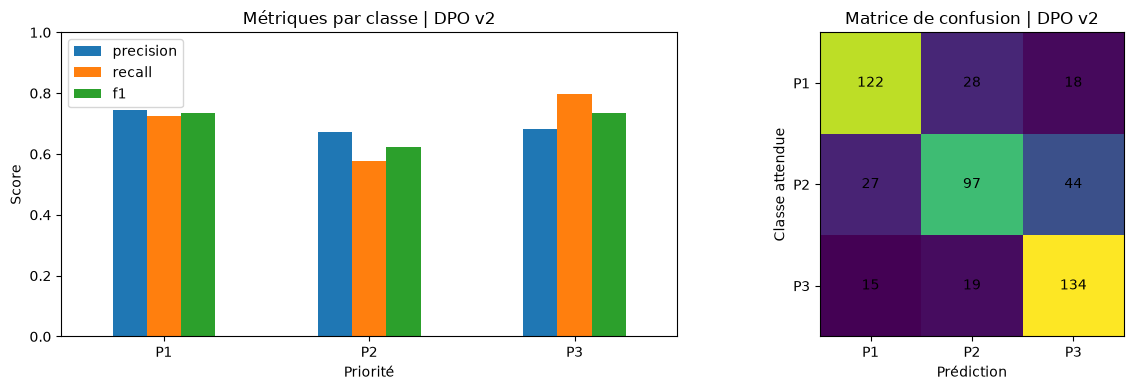

,stage,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,accuracy_en,f1_macro_en,accuracy_fr,f1_macro_fr
0,DPO v2,504,0.700397,0.700396,0.700397,0.697666,0.697666,0.746154,0.742836,0.651639,0.649905


,stage,transition,count,support,rate_pct
0,DPO v2,P1 → P2,28,168,16.666667
1,DPO v2,P1 → P3,18,168,10.714286
2,DPO v2,P2 → P3,44,168,26.190476


✓ Benchmark DPO sauvegardé


In [36]:
# Évalue le DPO final sur les 504 exemples figés.

dpo_results_df = score_priorities(
    dpo_trainer.model,
    splits["test"]
)

dpo_metrics, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    "DPO v2"
)

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    "DPO v2"
)

dpo_figure = display_evaluation(
    dpo_class_metrics,
    dpo_confusion,
    "DPO v2"
)

display(pd.DataFrame([dpo_metrics]))
display(dpo_undertriage)


# Sauvegarde le benchmark du run.

dpo_figure.savefig(
    RUN_METRIC_DIR / "dpo_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

write_jsonl(
    RUN_METRIC_DIR / "dpo_predictions.jsonl",
    dpo_results_df.to_dict("records")
)

write_jsonl(
    RUN_METRIC_DIR / "dpo_undertriage_details.jsonl",
    dpo_undertriage_details.to_dict("records")
)

(RUN_METRIC_DIR / "dpo_metrics.json").write_text(
    json.dumps(dpo_metrics, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

plt.close(dpo_figure)

print("✓ Benchmark DPO sauvegardé")

In [37]:
# Journalise le benchmark final DPO dans W&B.

dpo_test_run = start_wandb_run("dpo-test", {
    "test_rows": len(dpo_results_df),
    "inference_method": "conditional_priority_scoring",
    "source_sha256": file_sha256(DPO_PATH)
})

if dpo_test_run:
    dpo_test_run.log({
        **{
            f"test/{key}": value
            for key, value in dpo_metrics.items()
            if isinstance(value, (int, float))
        },
        "test/predictions": wandb.Table(dataframe=dpo_results_df),
        "test/undertriage": wandb.Table(dataframe=dpo_undertriage),
        "test/confusion_matrix": wandb.Image(
            str(RUN_METRIC_DIR / "dpo_confusion_matrix.png")
        )
    })

    dpo_test_run.finish()

test/accuracy,▁
test/accuracy_en,▁
test/accuracy_fr,▁
test/f1_macro,▁
test/f1_macro_en,▁
test/f1_macro_fr,▁
test/f1_weighted,▁
test/precision_macro,▁
test/recall_macro,▁
test/rows,▁
test/accuracy,0.7004


In [38]:
# Libère le DPO et la mémoire GPU.

for name in (
    "dpo_trainer",
    "model",
    "dpo_train_output"
):
    globals().pop(name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

    free, total = torch.cuda.mem_get_info()

    print(
        f"✓ DPO libéré | "
        f"VRAM libre : {free / 1024**3:.2f} / {total / 1024**3:.2f} Go"
    )

✓ DPO libéré | VRAM libre : 2.51 / 6.00 Go


## 10. Évaluation complète DPO

Je réutilise `test_df` sans le reconstruire ni le mélanger. Les IDs, classes attendues, prompts, paramètres de génération et fonctions de métriques restent donc strictement identiques au test SFT.


In [ ]:
stopici

## 11. Comparaison SFT/DPO

Je mesure les deltas globaux et par priorité, puis j’effectue un test de McNemar exact sur les succès appariés. Un DPO n’est considéré utile que si son amélioration est visible sur le test figé, notamment sur le rappel P1.


In [41]:
# Recharge les prédictions SFT et DPO du run.

prediction_paths = {
    "SFT": RUN_METRIC_DIR / "sft_predictions.jsonl",
    "DPO": RUN_METRIC_DIR / "dpo_predictions.jsonl"
}

results = {}

for stage, path in prediction_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Prédictions {stage} introuvables : {path}")

    df = pd.DataFrame(read_jsonl(path))

    assert len(df) == 504
    assert df["id"].is_unique

    results[stage] = df

sft_results_df = results["SFT"]
dpo_results_df = results["DPO"]

print(
    f"✓ SFT : {len(sft_results_df)} cas | "
    f"DPO : {len(dpo_results_df)} cas"
)

display(sft_results_df.head())
display(dpo_results_df.head())

✓ SFT : 504 cas | DPO : 504 cas


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,030121851978c9c14157239a,fr,1,1,PRIORITY: P1,-0.124450,-0.199450,-0.474450
1,03418500481f5d190f1c9a4c,fr,1,1,PRIORITY: P1,-0.042403,-0.367403,-0.692403
2,05beaa13d7fcec3bab30c4aa,fr,1,1,PRIORITY: P1,-0.002810,-0.927810,-1.102810
3,06db084fd6b189187e929295,fr,1,1,PRIORITY: P1,-0.069092,-0.269092,-0.694092
4,08edd077ae501af3739e2f7e,fr,1,1,PRIORITY: P1,-0.026204,-0.476204,-0.701204


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,030121851978c9c14157239a,fr,1,1,PRIORITY: P1,-0.134061,-0.184061,-0.484061
1,03418500481f5d190f1c9a4c,fr,1,1,PRIORITY: P1,-0.037199,-0.387199,-0.737199
2,05beaa13d7fcec3bab30c4aa,fr,1,1,PRIORITY: P1,-0.002812,-0.927812,-1.102812
3,06db084fd6b189187e929295,fr,1,1,PRIORITY: P1,-0.068356,-0.268356,-0.718356
4,08edd077ae501af3739e2f7e,fr,1,1,PRIORITY: P1,-0.025495,-0.475495,-0.725495


In [42]:
# Recharge les métriques SFT et DPO du run.

with (RUN_METRIC_DIR / "sft_metrics.json").open(
    encoding="utf-8"
) as file:
    sft_metrics = json.load(file)

with (RUN_METRIC_DIR / "dpo_metrics.json").open(
    encoding="utf-8"
) as file:
    dpo_metrics = json.load(file)

print("✓ Métriques SFT/DPO rechargées")

✓ Métriques SFT/DPO rechargées


In [44]:
# Recalcule les métriques SFT et DPO depuis les prédictions sauvegardées.

sft_metrics, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    "SFT v2"
)

dpo_metrics, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    "DPO v2"
)

print("✓ Métriques SFT/DPO recalculées")

✓ Métriques SFT/DPO recalculées


,metric,SFT v2,DPO v2,delta
0,accuracy,0.6984,0.7004,+0.0020
1,precision_macro,0.6986,0.7004,+0.0018
2,recall_macro,0.6984,0.7004,+0.0020
3,f1_macro,0.6954,0.6977,+0.0022
4,f1_weighted,0.6954,0.6977,+0.0022
5,precision_p1,0.7394,0.7439,+0.0045
6,recall_p1,0.7262,0.7262,+0.0000
7,f1_p1,0.7327,0.7349,+0.0022
8,precision_p2,0.6761,0.6736,-0.0024
9,recall_p2,0.5714,0.5774,+0.0060


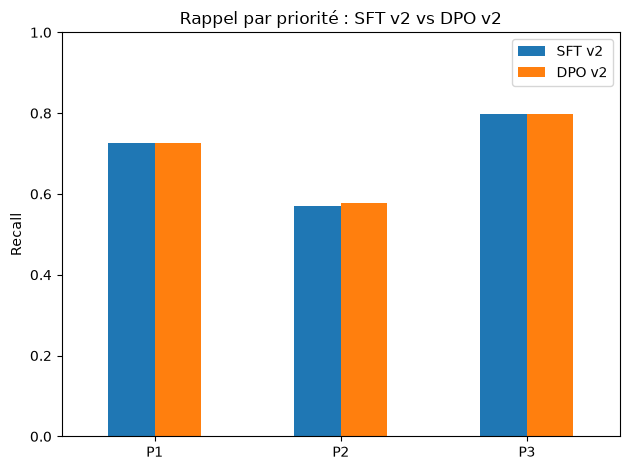

In [48]:
# Compare les métriques SFT v2 et DPO v2.

def comparison_metrics(metrics: dict, class_metrics: pd.DataFrame) -> dict:
    """Regroupe les métriques globales et par priorité."""
    values = {
        key: metrics[key]
        for key in (
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "f1_weighted"
        )
    }

    for priority in ("P1", "P2", "P3"):
        row = class_metrics.loc[
            class_metrics["class"] == priority
        ].iloc[0]

        suffix = priority.lower()

        values[f"precision_{suffix}"] = row["precision"]
        values[f"recall_{suffix}"] = row["recall"]
        values[f"f1_{suffix}"] = row["f1"]

    return values


sft_comparison = comparison_metrics(
    sft_metrics,
    sft_class_metrics
)

dpo_comparison = comparison_metrics(
    dpo_metrics,
    dpo_class_metrics
)

comparison_keys = list(sft_comparison)

metrics_comparison_df = pd.DataFrame({
    "metric": comparison_keys,
    "SFT v2": [sft_comparison[key] for key in comparison_keys],
    "DPO v2": [dpo_comparison[key] for key in comparison_keys]
})

metrics_comparison_df["delta"] = (
    metrics_comparison_df["DPO v2"]
    - metrics_comparison_df["SFT v2"]
)

display(
    metrics_comparison_df.style.format({
        "SFT v2": "{:.4f}",
        "DPO v2": "{:.4f}",
        "delta": "{:+.4f}"
    })
)

metrics_comparison_df.to_csv(
    RUN_METRIC_DIR / "sft_dpo_metrics_comparison.csv",
    index=False,
    encoding="utf-8"
)


# Compare visuellement le rappel P1/P2/P3.

recall_df = metrics_comparison_df[
    metrics_comparison_df["metric"].isin(
        ["recall_p1", "recall_p2", "recall_p3"]
    )
].set_index("metric")

ax = recall_df[["SFT v2", "DPO v2"]].plot.bar()

ax.set(
    ylim=(0, 1),
    xlabel="",
    ylabel="Recall",
    title="Rappel par priorité : SFT v2 vs DPO v2"
)

ax.set_xticklabels(["P1", "P2", "P3"], rotation=0)

plt.tight_layout()

recall_figure = ax.get_figure()

recall_figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_recall_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [50]:
# Recalcule le sous-triage depuis les prédictions sauvegardées.

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    "SFT v2"
)

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    "DPO v2"
)

In [51]:
# Compare le sous-triage SFT v2 et DPO v2.
# Delta négatif = réduction du sous-triage.

undertriage_comparison = sft_undertriage[
    ["transition", "count", "rate_pct"]
].merge(
    dpo_undertriage[["transition", "count", "rate_pct"]],
    on="transition",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

undertriage_comparison["count_delta"] = (
    undertriage_comparison["count_dpo"]
    - undertriage_comparison["count_sft"]
)

undertriage_comparison["rate_delta"] = (
    undertriage_comparison["rate_pct_dpo"]
    - undertriage_comparison["rate_pct_sft"]
).round(2)

display(undertriage_comparison)

undertriage_comparison.to_csv(
    RUN_METRIC_DIR / "sft_dpo_undertriage_comparison.csv",
    index=False,
    encoding="utf-8"
)

,transition,count_sft,rate_pct_sft,count_dpo,rate_pct_dpo,count_delta,rate_delta
0,P1 → P2,27,16.071429,28,16.666667,1,0.6
1,P1 → P3,19,11.309524,18,10.714286,-1,-0.6
2,P2 → P3,44,26.190476,44,26.190476,0,0.0


In [53]:
# Compare les succès SFT et DPO avec le test exact de McNemar.

paired = sft_results_df[
    ["id", "expected", "predicted"]
].merge(
    dpo_results_df[["id", "predicted"]],
    on="id",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

assert len(paired) == 504

paired["sft_correct"] = (
    paired["expected"] == paired["predicted_sft"]
)

paired["dpo_correct"] = (
    paired["expected"] == paired["predicted_dpo"]
)

sft_only = int(
    (paired["sft_correct"] & ~paired["dpo_correct"]).sum()
)

dpo_only = int(
    (~paired["sft_correct"] & paired["dpo_correct"]).sum()
)

discordant = sft_only + dpo_only

mcnemar_pvalue = (
    binomtest(dpo_only, discordant, p=0.5).pvalue
    if discordant
    else 1.0
)


# Analyse les transitions de prédictions.

transition_table = pd.crosstab(
    paired["predicted_sft"],
    paired["predicted_dpo"],
    rownames=["SFT"],
    colnames=["DPO"],
    dropna=False
)

summary_df = pd.DataFrame([{
    "SFT correct seul": sft_only,
    "DPO correct seul": dpo_only,
    "Discordants": discordant,
    "McNemar p-value": mcnemar_pvalue
}])

display(transition_table)
display(summary_df)


# Sauvegarde les résultats du run.

transition_table.to_csv(
    RUN_METRIC_DIR / "sft_dpo_prediction_transitions.csv",
    encoding="utf-8"
)

mcnemar_results = {
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "discordant": discordant,
    "p_value": float(mcnemar_pvalue)
}

(RUN_METRIC_DIR / "sft_dpo_mcnemar.json").write_text(
    json.dumps(mcnemar_results, indent=2),
    encoding="utf-8"
)

DPO,1,2,3
SFT,,,
1,164,1,0
2,0,142,0
3,0,1,196


,SFT correct seul,DPO correct seul,Discordants,McNemar p-value
0,0,1,1,1.0


89

In [54]:
# Résume factuellement l'effet du DPO sur le test commun.

macro_delta = (
    dpo_comparison["f1_macro"]
    - sft_comparison["f1_macro"]
)

p1_recall_delta = (
    dpo_comparison["recall_p1"]
    - sft_comparison["recall_p1"]
)

if macro_delta > 0 and p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1 et le rappel P1 "
        "sur le test commun."
    )
elif p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le rappel P1, tandis que le macro-F1 "
        "n'augmente pas."
    )
elif macro_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1, tandis que le rappel P1 "
        "n'augmente pas."
    )
else:
    conclusion = (
        "Le DPO n'augmente ni le macro-F1 ni le rappel P1 "
        "sur le test commun."
    )

comparison_payload = {
    "macro_f1_delta": float(macro_delta),
    "p1_recall_delta": float(p1_recall_delta),
    "mcnemar_pvalue": float(mcnemar_pvalue),
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "conclusion": conclusion
}

(RUN_METRIC_DIR / "sft_dpo_conclusion.json").write_text(
    json.dumps(
        comparison_payload,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

display(pd.DataFrame([comparison_payload]))

print(conclusion)
print(
    "Conclusion à compléter par la matrice de confusion, "
    "le sous-triage et l'analyse des erreurs."
)
print("✓ Comparaison SFT / DPO terminée")

,macro_f1_delta,p1_recall_delta,mcnemar_pvalue,sft_only_correct,dpo_only_correct,conclusion
0,0.002221,0.0,1.0,0,1,"Le DPO augmente le macro-F1, tandis que le rap..."


Le DPO augmente le macro-F1, tandis que le rappel P1 n'augmente pas.
Conclusion à compléter par la matrice de confusion, le sous-triage et l'analyse des erreurs.
✓ Comparaison SFT / DPO terminée


## 12. Conclusion et manifeste

Je termine en sauvegardant les versions, empreintes, chemins et métriques. Ce manifeste permet de relier un résultat aux données, aux adaptateurs et au groupe W&B qui l’ont produit.


In [56]:
# Rassemble les éléments nécessaires à la reproductibilité du run.

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "run_stamp": RUN_STAMP,
    "run_group": RUN_GROUP,
    "wandb_project": WANDB_PROJECT if USE_WANDB else None,
    "configuration": asdict(CONFIG),
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        )
    },
    "data": {
        "sft_path": str(SFT_PATH),
        "sft_sha256": file_sha256(SFT_PATH),
        "dpo_path": str(DPO_PATH),
        "dpo_sha256": file_sha256(DPO_PATH),
        "test_rows": len(sft_results_df),
        "dpo_leakage_removed": leakage_count
    },
    "models": {
        "sft_adapter": str(SFT_MODEL_PATH),
        "dpo_adapter": str(DPO_MODEL_PATH)
    },
    "results": {
        "sft": {
            "global": sft_metrics,
            "per_class": sft_class_metrics.to_dict("records")
        },
        "dpo": {
            "global": dpo_metrics,
            "per_class": dpo_class_metrics.to_dict("records")
        },
        "comparison": comparison_payload
    }
}

MANIFEST_PATH = RUN_METRIC_DIR / "experiment_manifest.json"

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        ensure_ascii=False,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)

print("=== CONCLUSION ===")
print(conclusion)
print(f"Manifest : {MANIFEST_PATH}")
print(f"Groupe W&B : {RUN_GROUP}")

=== CONCLUSION ===
Le DPO augmente le macro-F1, tandis que le rappel P1 n'augmente pas.
Manifest : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20260922-195422\experiment_manifest.json
Groupe W&B : qwen3-triage-20260922-195422


Références techniques : [TRL SFTTrainer](https://huggingface.co/docs/trl/main/en/sft_trainer), [TRL DPOTrainer](https://huggingface.co/docs/trl/main/en/dpo_trainer), [W&B × Transformers](https://docs.wandb.ai/models/integrations/huggingface), [quantification bitsandbytes](https://huggingface.co/docs/transformers/main/en/quantization/bitsandbytes).
